# Monte Carlo Simulation for Investment Risk and Strategy Analysis

## Problem Statement

Investing in financial markets involves uncertainty and risk. 
This project focuses on analyzing investment outcomes using probabilistic simulations. 
The goal of this project is to model and analyze investment outcomes using probabilistic methods.

We aim to answer the following questions:

- What is the expected return of an investment?
- What is the probability of loss?
- How does risk affect long-term outcomes?
- How do different strategies compare?

---

## Assumptions

- Returns follow a normal distribution
- Markets behave randomly in the short term
- No transaction costs or taxes

## Mathematical Model

We assume that returns follow a normal distribution:

$$ R \sim N(\mu, \sigma) $$

Where:
- $\mu$ is the expected return
- $\sigma$ is the volatility

The portfolio value evolves as:

$$ V_t = V_0 \cdot (1 + R_t) $$

This process is repeated over time.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

## Simulation Function

In this section, we define a function that simulates the evolution of an investment over time.
We assume that returns follow a normal distribution.

In [9]:
def simulate_investment(initial, months, mu, sigma):
    returns = np.random.normal(mu, sigma, months)
    
    value = initial
    values = []
    
    for r in returns:
        value *= (1 + r)
        values.append(value)
    
    return values

## Running Multiple Simulations

To better understand uncertainty, we run multiple simulations.

Each simulation represents a possible future scenario of the market.

By generating many scenarios, we can analyze the distribution of outcomes.

In [11]:
initial = 10000
months = 120
simulations = 200

results = []

for _ in range(simulations):
    results.append(simulate_investment(initial, months, 0.01, 0.05))

## Visualization of Simulation Paths

Below we plot all simulated investment paths.

Each line represents one possible future scenario.

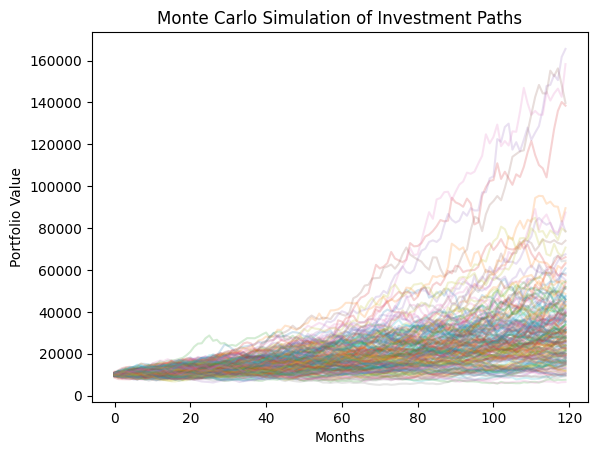

In [12]:
for path in results:
    plt.plot(path, alpha=0.2)

plt.title("Monte Carlo Simulation of Investment Paths")
plt.xlabel("Months")
plt.ylabel("Portfolio Value")

plt.show()

## Distribution of Final Outcomes

To better understand the risk, we analyze the distribution of final portfolio values.

This allows us to see how often different outcomes occur.

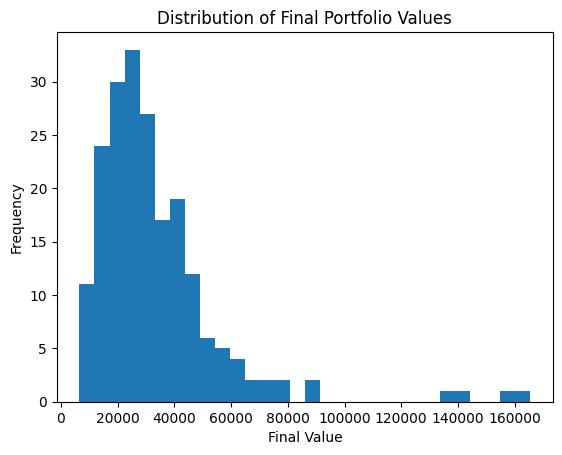

In [13]:
final_values = [path[-1] for path in results]

plt.hist(final_values, bins=30)

plt.title("Distribution of Final Portfolio Values")
plt.xlabel("Final Value")
plt.ylabel("Frequency")

plt.show()

## Statistical Analysis

We compute key statistics to summarize the results:

- Mean (expected value)
- Minimum and maximum outcomes
- Probability of loss

In [15]:
mean = np.mean(final_values)
minimum = np.min(final_values)
maximum = np.max(final_values)

print("Average:", mean)
print("Min:", minimum)
print("Max:", maximum)

# probability of losing money
prob_loss = np.mean(np.array(final_values) < initial)
print("Probability of loss:", prob_loss)

Average: 33540.77305911742
Min: 6514.510388357007
Max: 165538.437722371
Probability of loss: 0.025


## Strategy Comparison: Lump Sum vs Dollar-Cost Averaging (DCA)

In this section, we compare two common investment strategies:

- Lump Sum: investing the entire amount at once
- Dollar-Cost Averaging (DCA): investing equal amounts periodically

The goal is to analyze how these strategies perform under uncertainty.

### Lump Sum Strategy

In the lump sum strategy, the entire investment is made at the beginning.
The portfolio then evolves according to market returns.

In [17]:
def simulate_lump_sum(initial, months, mu, sigma):
    return simulate_investment(initial, months, mu, sigma)

### Dollar-Cost Averaging (DCA)

In this strategy, the total investment is divided into equal monthly contributions.

This reduces the risk of investing at a bad time.

In [18]:
def simulate_dca(monthly_investment, months, mu, sigma):
    returns = np.random.normal(mu, sigma, months)
    
    value = 0
    values = []
    
    for r in returns:
        value = (value + monthly_investment) * (1 + r)
        values.append(value)
    
    return values

## Running Strategy Comparison

We simulate both strategies under the same market conditions.

In [19]:
months = 120
simulations = 200

lump_results = []
dca_results = []

for _ in range(simulations):
    lump = simulate_lump_sum(10000, months, 0.01, 0.05)
    dca = simulate_dca(10000 / months, months, 0.01, 0.05)
    
    lump_results.append(lump[-1])
    dca_results.append(dca[-1])

## Comparison of Final Results

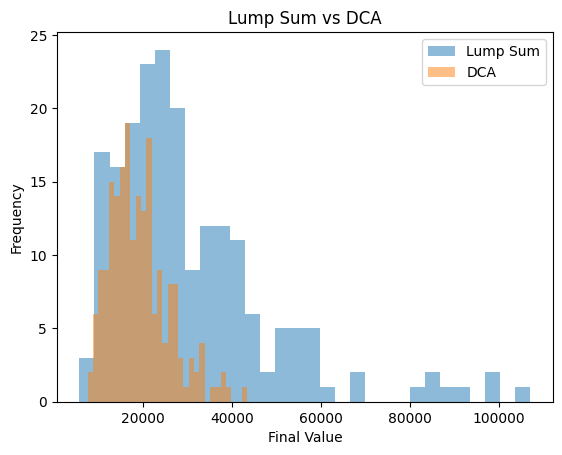

In [20]:
plt.hist(lump_results, bins=30, alpha=0.5, label="Lump Sum")
plt.hist(dca_results, bins=30, alpha=0.5, label="DCA")

plt.legend()
plt.title("Lump Sum vs DCA")
plt.xlabel("Final Value")
plt.ylabel("Frequency")

plt.show()

## Strategy Analysis

We compare the average outcomes of both strategies.

In [21]:
print("Lump Sum Average:", np.mean(lump_results))
print("DCA Average:", np.mean(dca_results))

Lump Sum Average: 30575.522269457317
DCA Average: 19248.168870744303


## Interpretation

Lump sum investing generally leads to higher average returns because the money is invested earlier.

However, DCA reduces risk by spreading investments over time, which can be beneficial in volatile markets.

This demonstrates the trade-off between risk and return.

This highlights the uncertainty inherent in financial markets.

## Conclusion

In this project, we used Monte Carlo simulation to model investment behavior under uncertainty.

We demonstrated that while the expected return of an investment may be positive, there is always a non-zero probability of loss.

We also compared two common strategies: Lump Sum and Dollar-Cost Averaging (DCA).

The results show that:
- Lump Sum tends to produce higher returns on average
- DCA reduces risk by spreading investment over time

This highlights the fundamental trade-off between risk and return.

These results emphasize the importance of long-term investing.

---

## Final Thoughts

Monte Carlo methods are powerful tools for understanding uncertainty and risk.

Although our model is simplified, it provides useful insights into real-world investing decisions.

Future improvements could include:
- More realistic return distributions
- Transaction costs
- Inflation adjustments

In [22]:
prob_profit_lump = np.mean(np.array(lump_results) > 10000)
prob_profit_dca = np.mean(np.array(dca_results) > 10000)

print("Lump Sum Profit Probability:", prob_profit_lump)
print("DCA Profit Probability:", prob_profit_dca)

Lump Sum Profit Probability: 0.965
DCA Profit Probability: 0.96
